Importing libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report

from sklearn.metrics import roc_auc_score

from sklearn.metrics import roc_curve

from sklearn.metrics import accuracy_score

from sklearn.metrics import precision_score

from sklearn.metrics import recall_score

from sklearn.metrics import f1_score

In [ ]:
df_ai4i = pd.read_csv("/content/sample_data/ai4i2020.csv")
df_ai4i

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [ ]:
df_ai4i.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
# Checking duplicate rows

df_ai4i = df_ai4i.drop_duplicates()
df_ai4i

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [ ]:
df_ai4i.isnull().sum()


,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [ ]:

df_ai4i.duplicated().sum()

np.int64(0)

# **EDA**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Improve plot appearance
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [ ]:
# dataset dimension
print("Rows:", df_ai4i.shape[0])
print("Columns:", df_ai4i.shape[1])

Rows: 10000
Columns: 14


In [ ]:
missing = df_ai4i.isnull().sum()/len(df_ai4i)*100

missing.sort_values(ascending=False)

,0
UDI,0.0
Product ID,0.0
Type,0.0
Air temperature [K],0.0
Process temperature [K],0.0
Rotational speed [rpm],0.0
Torque [Nm],0.0
Tool wear [min],0.0
Machine failure,0.0
TWF,0.0


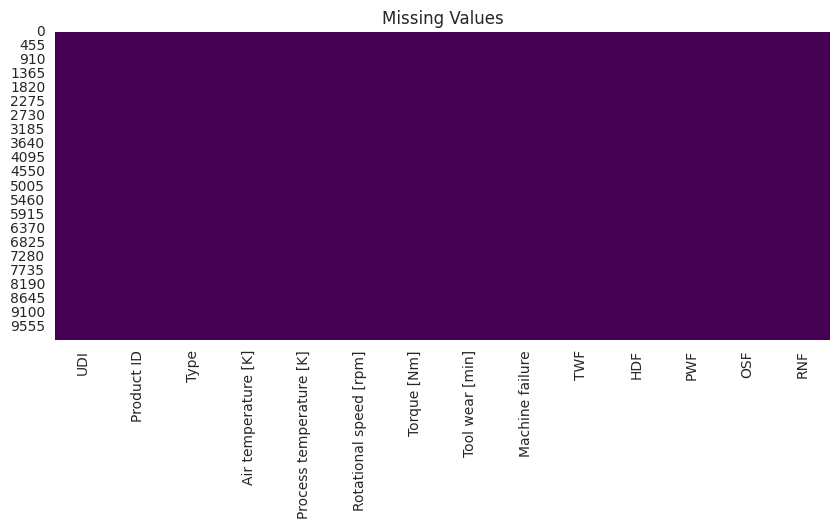

In [ ]:
plt.figure(figsize=(10,4))

sns.heatmap(df_ai4i.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values")
plt.show()

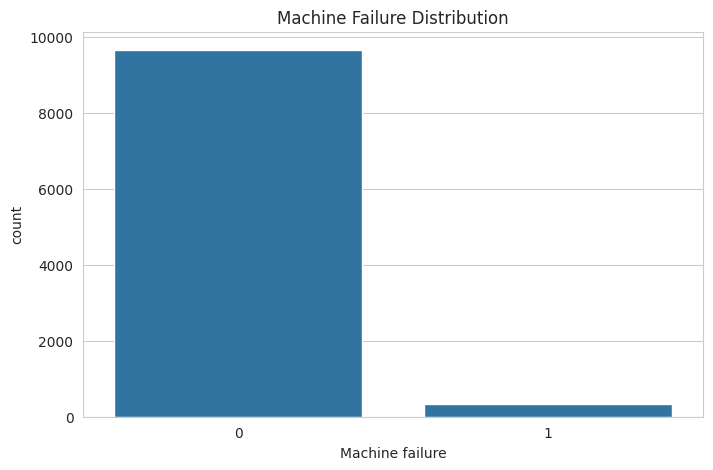

In [ ]:
sns.countplot(data=df_ai4i,
              x='Machine failure')

plt.title("Machine Failure Distribution")
plt.show()

In [ ]:
# Normalized
df_ai4i['Machine failure'].value_counts(normalize=True)*100

,proportion
Machine failure,
0,96.61
1,3.39


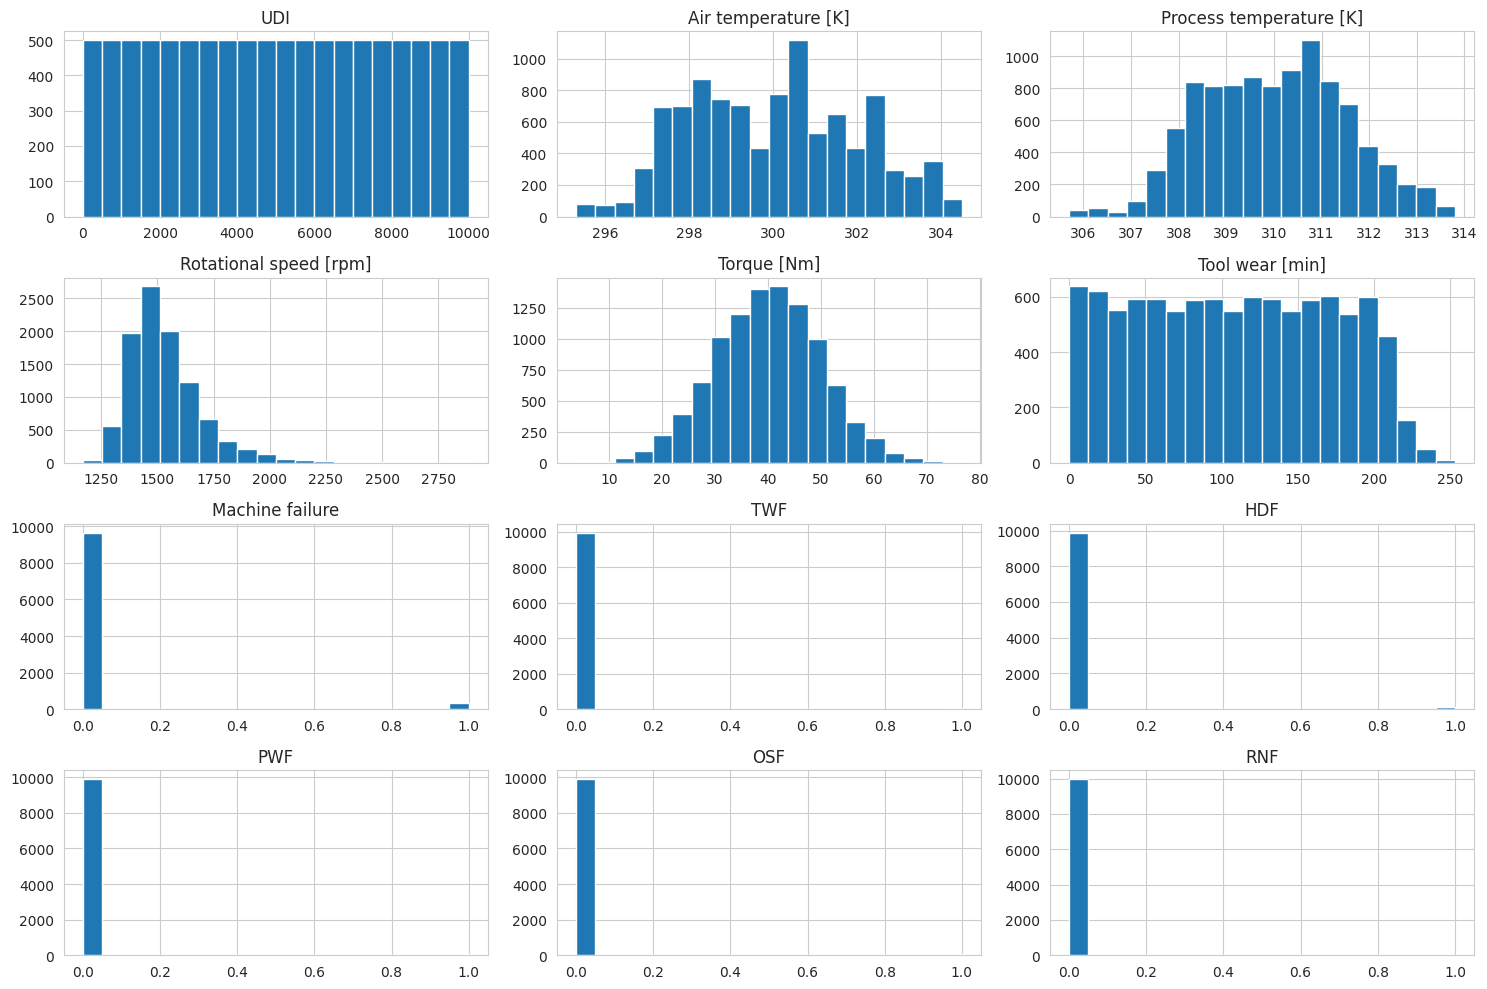

In [ ]:
num_cols = df_ai4i.select_dtypes(include=['int64','float64']).columns

df_ai4i[num_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

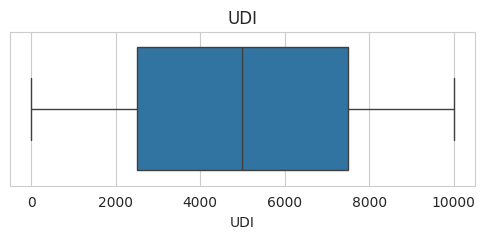

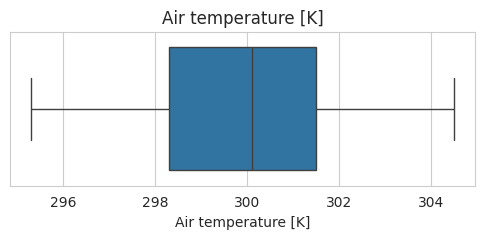

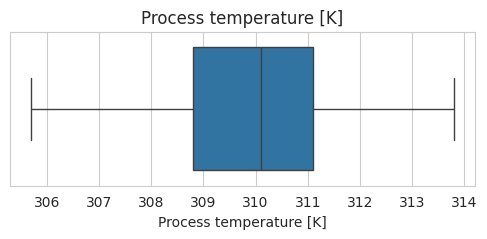

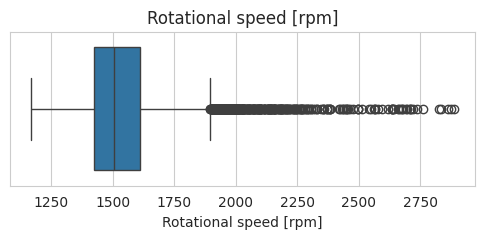

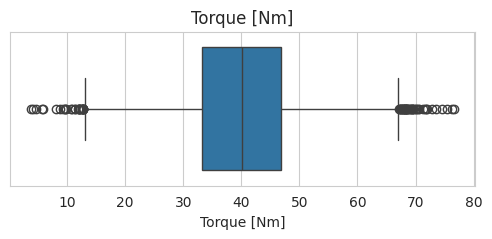

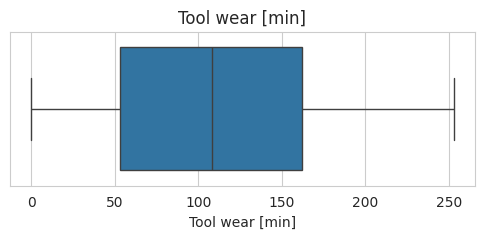

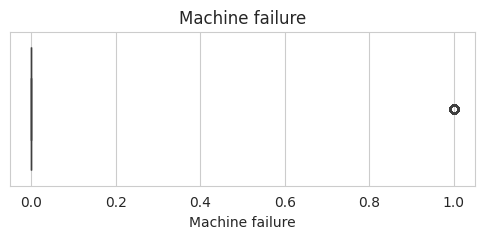

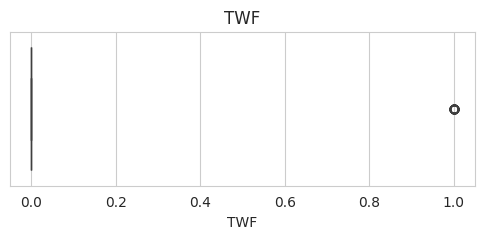

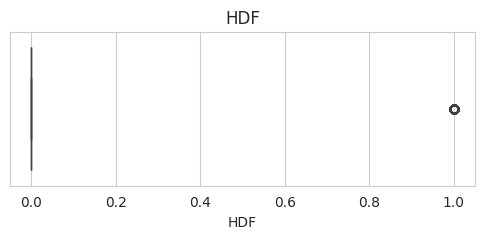

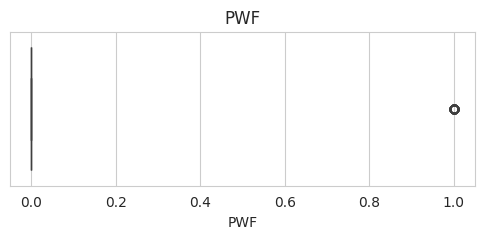

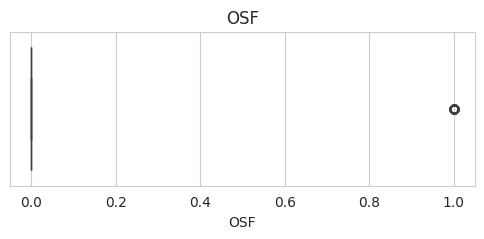

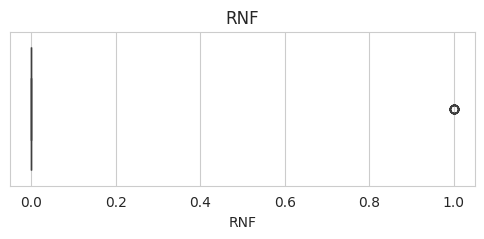

In [ ]:
# Outlier detection
for col in num_cols:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=df_ai4i[col])

    plt.title(col)

    plt.show()

Correlation Heatmap

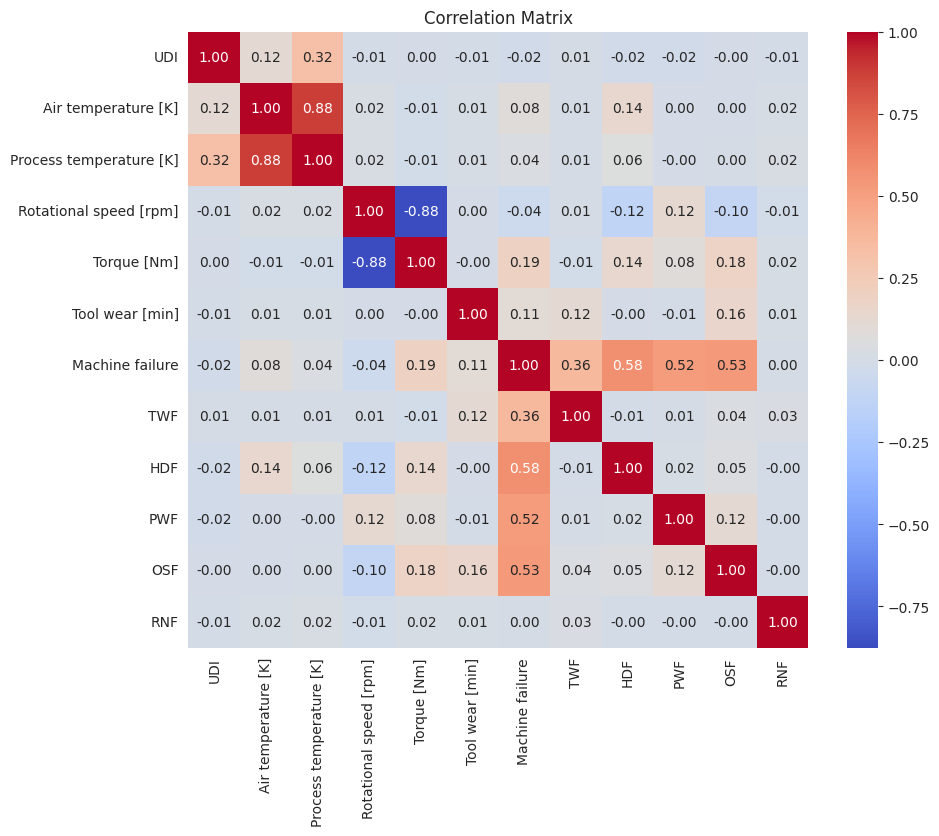

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df_ai4i[num_cols].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

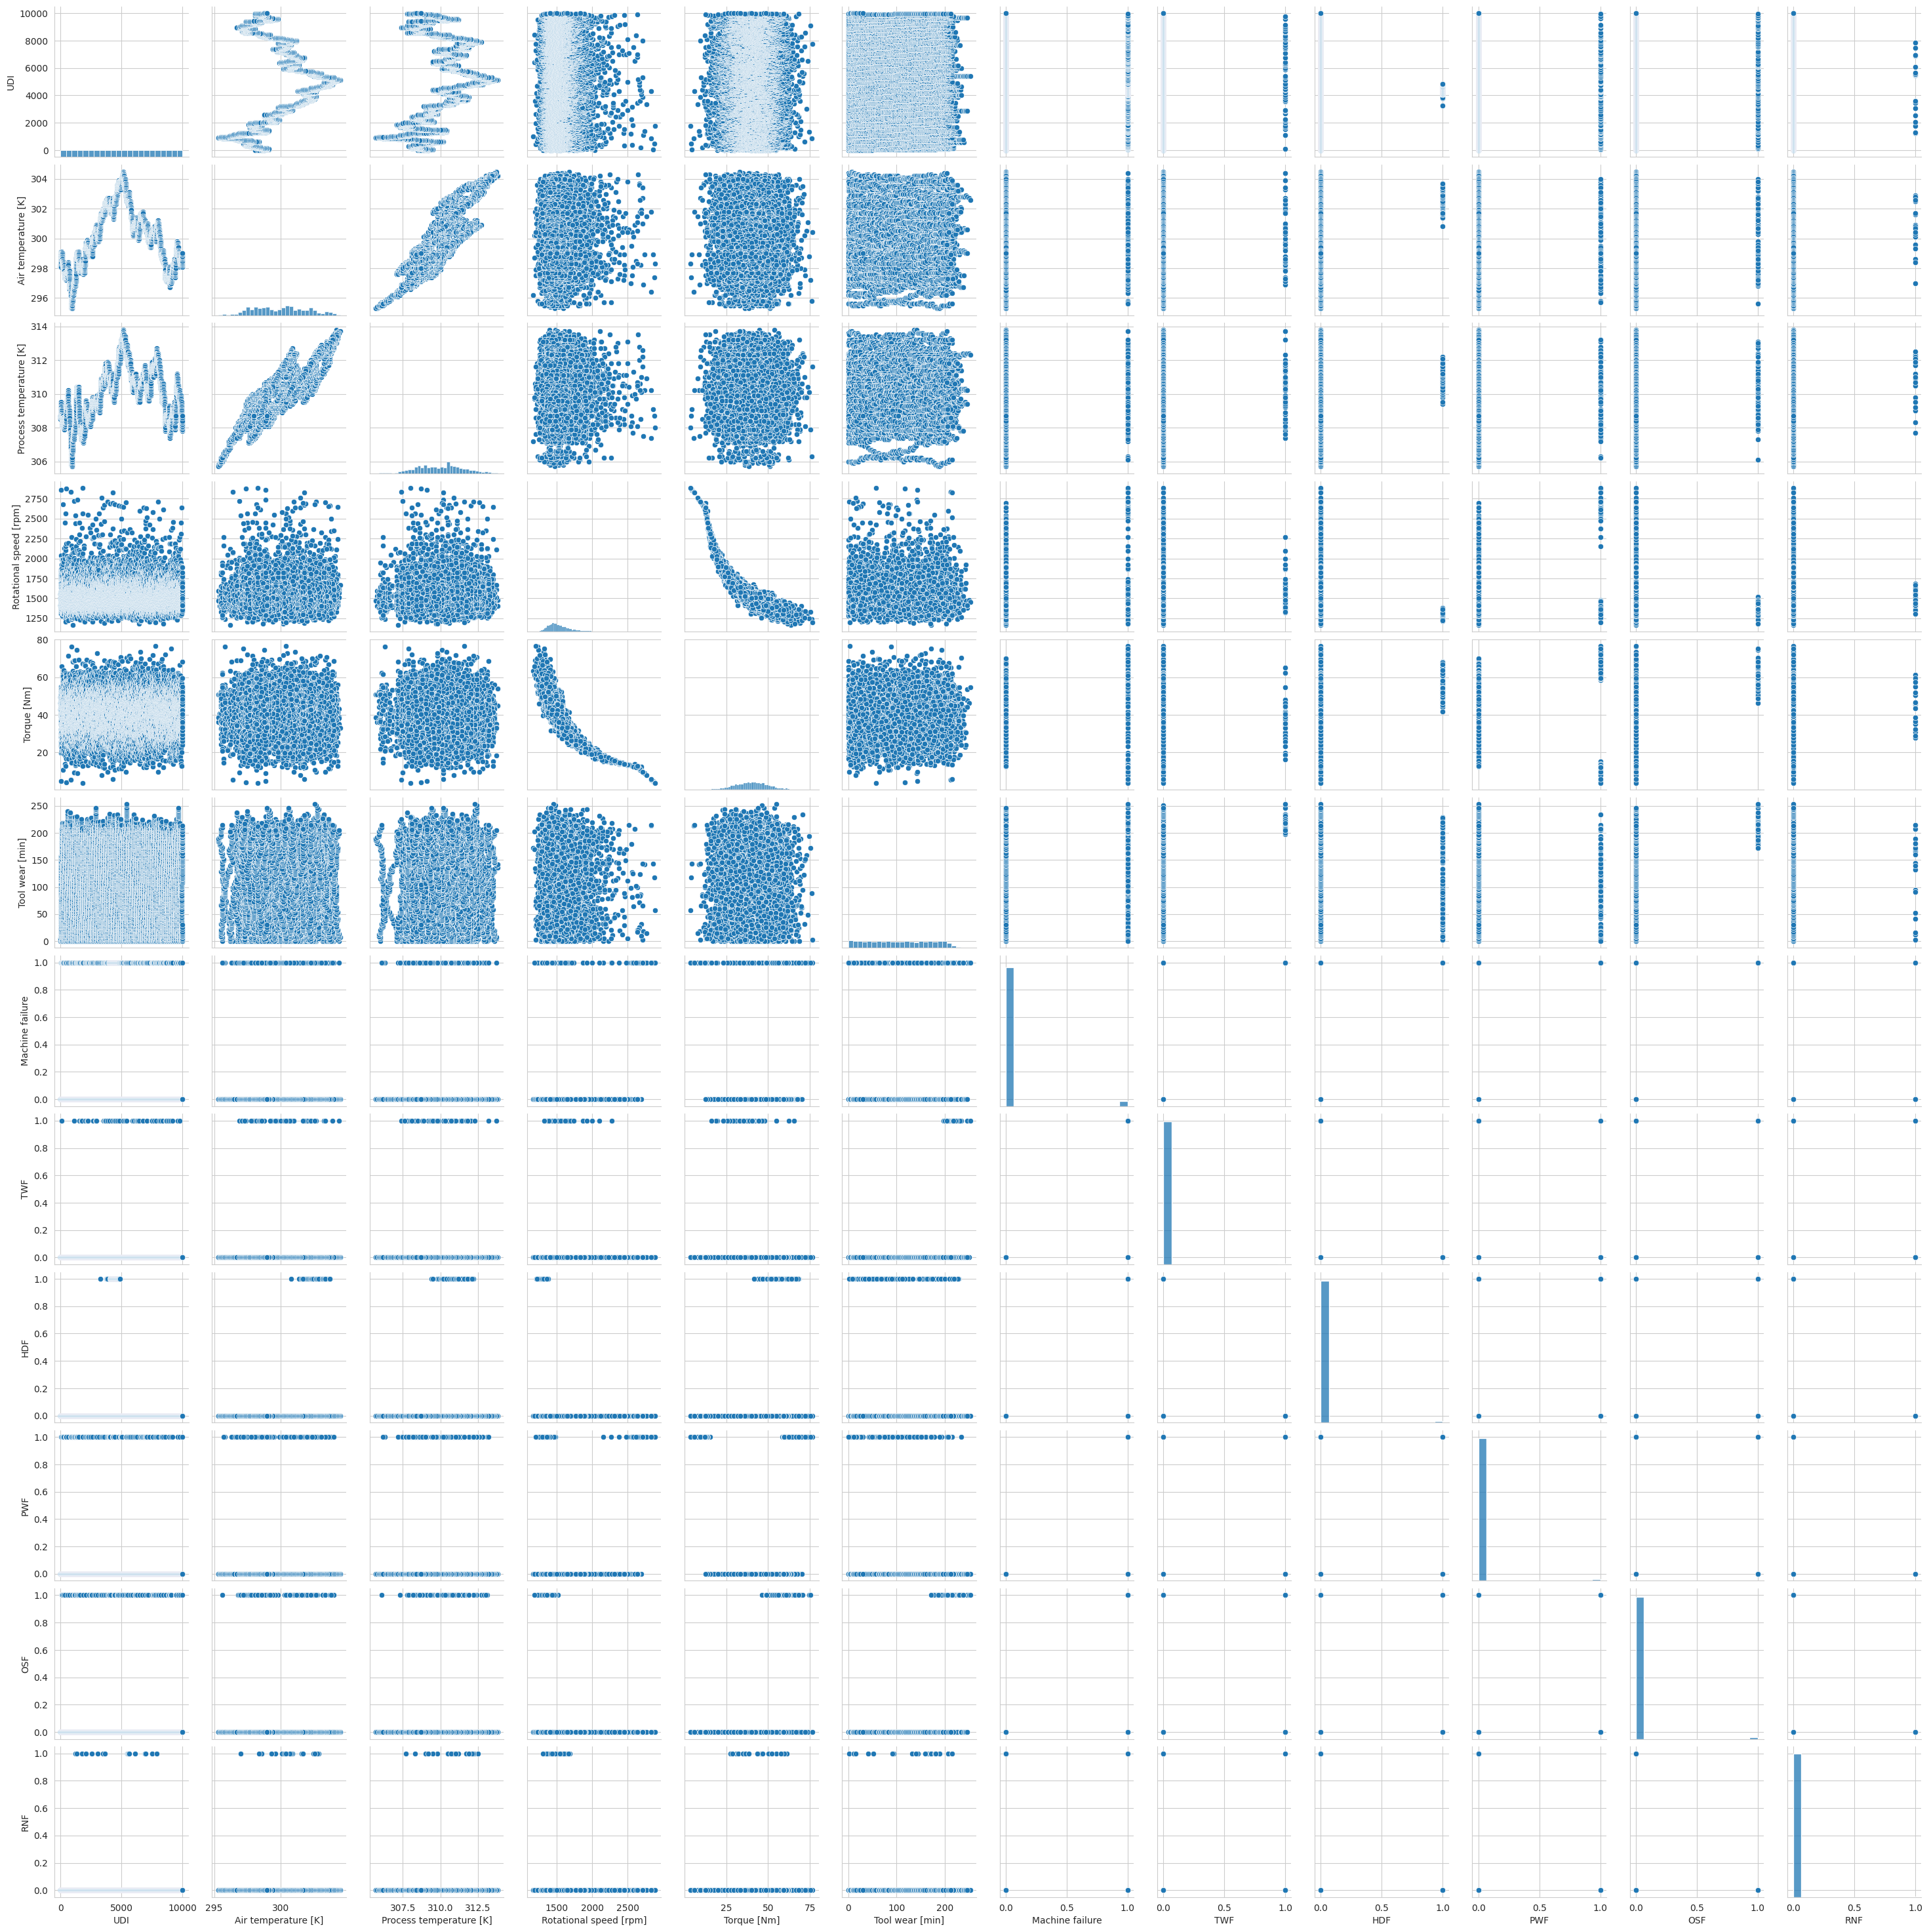

In [ ]:
sns.pairplot(
    df_ai4i[num_cols]
)

plt.show()

In [ ]:
#Categorical vriables
cat_cols = df_ai4i.select_dtypes(include='object').columns

cat_cols

Index(['Product ID', 'Type'], dtype='object')

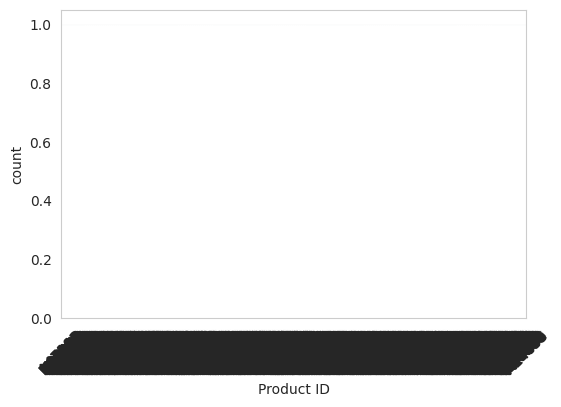

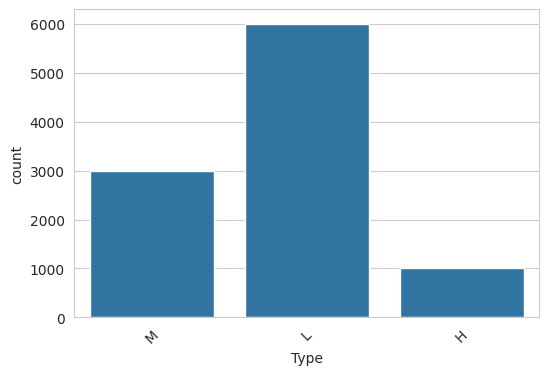

In [ ]:
for col in cat_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(data=df_ai4i,
                  x=col)

    plt.xticks(rotation=45)

    plt.show()

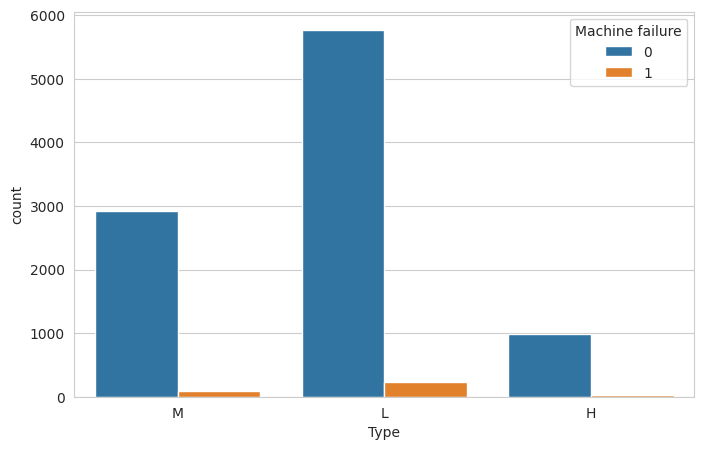

In [ ]:
# Machine failure by Product Type
sns.countplot(data=df_ai4i,
              x='Type',
              hue='Machine failure')

plt.show()

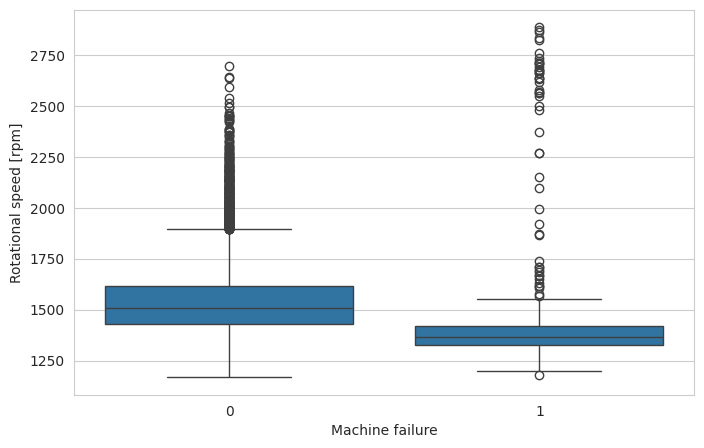

In [ ]:
# Rotational speed [rpm] vs Machine failure
sns.boxplot(
    x='Machine failure',
    y='Rotational speed [rpm]',
    data=df_ai4i
)

plt.show()

# **Feature Selection**

In [ ]:
# Features (X)
X = df_ai4i.drop('Machine failure', axis=1)

# Target (y)
y = df_ai4i['Machine failure']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 13)
Target Shape: (10000,)


In [ ]:
print("Selected Features:\n")
print(X.columns.tolist())

Selected Features:

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [ ]:
X.dtypes


,0
UDI,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
TWF,int64
HDF,int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in X.select_dtypes(include='object').columns:
    X[column] = le.fit_transform(X[column])

print("Encoding Complete!")

Encoding Complete!


In [ ]:
# Train-Test Split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Complete!")

Scaling Complete!


In [ ]:
X_train
X_test

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
2997,2998,2801,1,300.5,309.8,1345,62.7,153,0,0,0,0,0
4871,4872,3946,1,303.7,312.4,1513,40.1,135,0,0,0,0,0
3858,3859,3317,1,302.5,311.4,1559,37.6,209,0,0,0,0,0
951,952,109,0,295.6,306.3,1509,35.8,60,0,0,0,0,0
6463,6464,640,0,300.5,310.0,1358,60.4,102,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1686,1687,194,0,297.9,307.3,1663,28.7,7,0,0,0,0,0
6952,6953,5179,1,300.8,311.3,1498,40.2,73,0,0,0,0,0
9954,9955,9986,2,298.1,307.9,1446,42.8,121,0,0,0,0,0
5728,5729,8717,2,302.4,311.9,1422,46.4,194,0,0,0,0,0


# **Applying RF**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

In [ ]:
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [ ]:
y_prob = rf_model.predict_proba(X_test)[:,1]

In [ ]:
y_pred = rf_model.predict(X_test)
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

results.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


# **Model performance**

In [ ]:
# Accuracy
train_accuracy = rf_model.score(X_train, y_train)

print("Training Accuracy:", round(train_accuracy*100,2), "%")

Training Accuracy: 100.0 %


In [ ]:
test_accuracy = rf_model.score(X_test, y_test)

print("Testing Accuracy:", round(test_accuracy*100,2), "%")

Testing Accuracy: 99.9 %
